# Week 5, Exercise 5.5: Curve Length Evaluation

This notebook evaluates the length of a curve using numerical and (optionally) analytical methods.

**Reference:** Eq. 4.2 and Eq. 4.5 in the LMLG book

## Imports and Setup

In [57]:
import numpy as np
from typing import Callable, Optional
import matplotlib.pyplot as plt

## Numerical Curve Length Evaluation (Eq. 4.2)

Compute the curve length numerically using finite differences:
$$L = \int_0^1 ||\dot{c}(t)|| \, dt \approx \sum_i ||c(t_{i+1}) - c(t_i)||$$

In [58]:
def evaluate_curve_length_numerical(
    curve: Callable[[np.ndarray], np.ndarray],
    t_values: np.ndarray
) -> float:
    """
    Evaluate the length of a curve numerically using Eq. 4.2 (LMLG book).
    
    Args:
        curve: A callable that takes a 1D array of t values and returns curve points
               Shape: (n_points, 2) for a 2D curve
        t_values: Array of parameter values t ∈ [0, 1]
        
    Returns:
        The estimated length of the curve
    """
    # Get curve points at all t values
    points = curve(t_values)  # Shape: (n_points, 2)
    
    differences =  points[1:] - points[:-1]
    
    distances = np.linalg.norm(differences, axis=1)
    
    curve_length = np.sum(distances)
    
    return curve_length

## Analytical Curve Length Evaluation (Eq. 4.5)

Compute the curve length analytically using the derivative norm:
$$L = \int_0^1 ||\dot{c}(t)|| \, dt \approx \sum_i ||\dot{c}(t_i)|| \cdot \Delta t$$

This requires the analytical derivative $||\dot{c}(t)||$ instead of finite differences.

In [59]:
def evaluate_curve_length_analytical(
    curve_derivative: Callable[[np.ndarray], np.ndarray],
    t_values: np.ndarray
) -> float:
    """
    Evaluate the length of a curve analytically using Eq. 4.5 (LMLG book).
    
    Args:
        curve_derivative: A callable that computes ||ċ(t)|| (norm of derivative)
                         Takes a 1D array of t values and returns the derivative norm
        t_values: Array of parameter values t ∈ [0, 1]
        
    Returns:
        The estimated length of the curve
    """
    # Compute ||ċ(t)|| at all t values
    derivative_norms = curve_derivative(t_values)
    
    # Integrate using the trapezoid rule
    curve_length = np.trapz(derivative_norms, t_values)

    return curve_length

## Define Your Curve

TODO: Replace with the actual curve from Eq. 17 in the week 5 exercises

In [60]:
def curve(t):
    """
    Define the curve c(t) from Eq. 17.
    
    Args:
        t: Parameter value(s), can be scalar or array
        
    Returns:
        Curve point(s) of shape (len(t), 2) for 2D curve
    """
    t = np.atleast_1d(t)
    x = 2 * t + 1
    y = -1 * t**2  
    return np.column_stack([x, y])


def curve_derivative_norm(t):
    """
    Compute ||ċ(t)|| (norm of the derivative).
    
    TODO: Replace with analytical derivative norm if available
    
    Args:
        t: Parameter value(s)
        
    Returns:
        Norm of the derivative at t
    """
    t = np.atleast_1d(t)
    return 2 * np.sqrt(1 + t**2)

## Run Evaluation

In [61]:
# Setup
n_points = 10
t_values = np.linspace(0, 1, n_points)

print("="*50)
print("Curve Length Evaluation Exercise 5.5")
print("="*50)

# Numerical evaluation (Eq. 4.2)
length_numerical = evaluate_curve_length_numerical(curve, t_values)
print(f"\nNumerical curve length (Eq. 4.2): {length_numerical}")

# Analytical evaluation (Eq. 4.5) - if implemented
length_analytical = evaluate_curve_length_analytical(curve_derivative_norm, t_values)
print(f"Analytical curve length (Eq. 4.5): {length_analytical}")

# Comparison
if length_numerical is not None and length_analytical is not None:
    relative_error = abs(length_numerical - length_analytical) / length_analytical * 100
    print(f"\nRelative error: {relative_error:.2f}%")

Curve Length Evaluation Exercise 5.5

Numerical curve length (Eq. 4.2): 2.294859476897697
Analytical curve length (Eq. 4.5): 2.2970423260635338

Relative error: 0.10%


C:\Users\nick\AppData\Local\Temp\ipykernel_16648\2888807342.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  curve_length = np.trapz(derivative_norms, t_values)


## Visualization

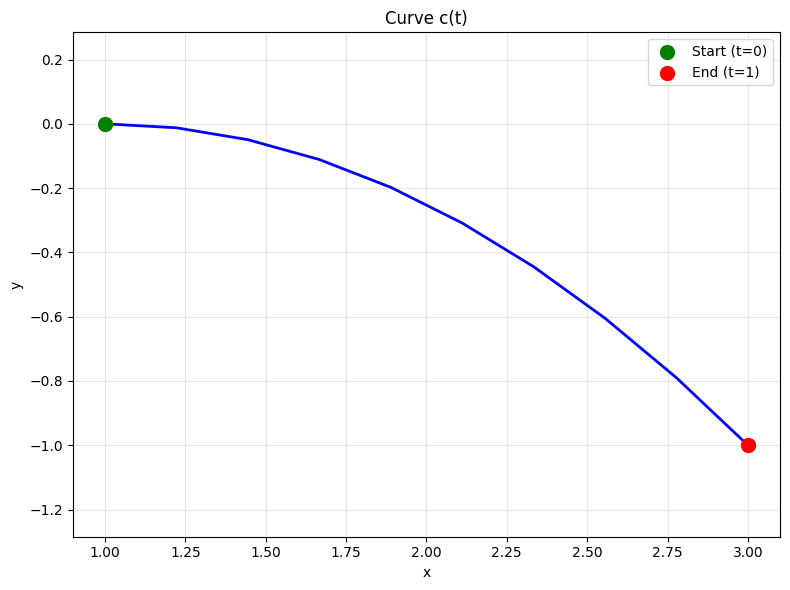

In [62]:
points = curve(t_values)

plt.figure(figsize=(8, 6))
plt.plot(points[:, 0], points[:, 1], 'b-', linewidth=2)
plt.scatter(points[0, 0], points[0, 1], color='g', s=100, label='Start (t=0)', zorder=5)
plt.scatter(points[-1, 0], points[-1, 1], color='r', s=100, label='End (t=1)', zorder=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curve c(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()